# Relative Astrometry Fitting

`jaxoplanet` can compute the position of a secondary body relative to a primary star on the sky.
We demonstrate this functionality by following the [astrometric fitting example](https://gallery.exoplanet.codes/tutorials/astrometric/) from the `exoplanet` example gallery.

```{note}
This tutorial requires some [extra packages](about.ipynb) that are not included in the `jaxoplanet` dependencies.
```

Let us first do the basic jax import and setup

In [1]:
import jax
import numpyro

# For multi-core parallelism (useful when running multiple MCMC chains in parallel)
numpyro.set_host_device_count(2)

# For CPU (use "gpu" for GPU)
numpyro.set_platform("cpu")

jax.config.update("jax_enable_x64", True)

## Data

First we download the data exactly like in the `exoplanet` tutorial. The data consists of HR 466 (HD 10009) astrometric measurements from [Pourbaix 1998](https://ui.adsabs.harvard.edu/#abs/1998A&AS..131..377P/abstract). The speckle observations are originally from [Hartkopf et al. 1996](https://ui.adsabs.harvard.edu/#abs/1996AJ....111..370H/abstract).

The code below is copied directly from the `exoplanet` tutorial.

In [2]:
from astropy.io import ascii
from astropy.time import Time

# grab the formatted data and do some munging
dirname = "https://gist.github.com/iancze/262aba2429cb9aee3fd5b5e1a4582d4d/raw/c5fa5bc39fec90d2cc2e736eed479099e3e598e3/"

astro_data_full = ascii.read(
    dirname + "astro.txt", format="csv", fill_values=[(".", "0")]
)

# convert UT date to JD
astro_dates = Time(astro_data_full["date"].data, format="decimalyear")

# Following the Pourbaix et al. 1998 analysis, we'll limit ourselves to the highest quality data
# since the raw collection of data outside of these ranges has some ambiguities in swapping
# the primary and secondary star
ind = (
    (astro_dates.value > 1975.0)
    & (astro_dates.value < 1999.73)
    & (~astro_data_full["rho"].mask)
    & (~astro_data_full["PA"].mask)
)

astro_data = astro_data_full[ind]

astro_yrs = astro_data["date"]
astro_dates.format = "jd"
astro_jds = astro_dates[ind].value

/home/vandal/miniforge3/envs/jaxoplanet/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 6 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/vandal/miniforge3/envs/jaxoplanet/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 5 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/vandal/miniforge3/envs/jaxoplanet/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 5 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/vandal/miniforge3/envs/jaxoplanet/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 6 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/vandal/miniforge3/envs/jaxoplanet/lib/python3.14/site-packages/erfa/core.py:133: ErfaWar

In [3]:
import numpy as np

astro_data["rho_err"][astro_data["rho_err"].mask == True] = 0.01
astro_data["PA_err"][astro_data["PA_err"].mask == True] = 1.0

# Convert all masked frames to be raw np arrays, since theano has issues with astropy masked columns
rho_data = np.ascontiguousarray(astro_data["rho"], dtype=float)  # arcsec
rho_err = np.ascontiguousarray(astro_data["rho_err"], dtype=float)

# The position angle measurements come in degrees in the range [0, 360].
# We'll convert this to radians in the range [-pi, pi]
deg = np.pi / 180.0
theta_data = np.ascontiguousarray(astro_data["PA"] * deg, dtype=float)
theta_data[theta_data > np.pi] -= 2 * np.pi

theta_err = np.ascontiguousarray(astro_data["PA_err"] * deg)  # radians

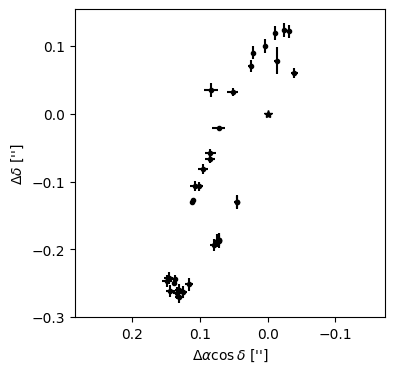

In [4]:
import matplotlib.pyplot as plt

# Make a plot of the astrometric data on the sky
# The convention is that North is up and East is left
fig, ax = plt.subplots(nrows=1, figsize=(4, 4))

xs_data = rho_data * np.cos(theta_data)  # X is north
ys_data = rho_data * np.sin(theta_data)  # Y is east

xs_data_err = np.sqrt(
    (np.cos(theta_data)**2 * rho_err**2) +
    (rho_data**2 * np.sin(theta_data)**2 * theta_err**2)
)
ys_data_err = np.sqrt(
    (np.sin(theta_data)**2 * rho_err**2) +
    (rho_data**2 * np.cos(theta_data)**2 * theta_err**2)
)

ax.errorbar(ys_data, xs_data, xerr=ys_data_err, yerr=xs_data_err, fmt=".k")
ax.set_ylabel(r"$\Delta \delta$ ['']")
ax.set_xlabel(r"$\Delta \alpha \cos \delta$ ['']")
ax.invert_xaxis()
ax.plot(0, 0, "k*")
ax.set_aspect("equal", "datalim")
plt.show()

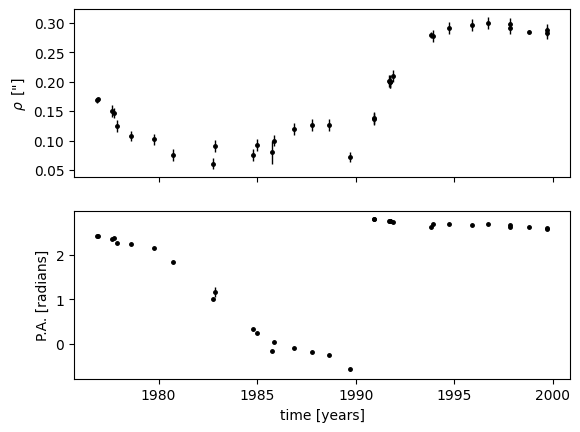

In [5]:
fig, ax = plt.subplots(nrows=2, sharex=True)
ax[0].errorbar(astro_yrs, rho_data, yerr=rho_err, fmt=".k", lw=1, ms=5)
ax[0].set_ylabel(r'$\rho\,$ ["]')

ax[1].errorbar(astro_yrs, theta_data, yerr=theta_err, fmt=".k", lw=1, ms=5)
ax[1].set_ylabel(r"P.A. [radians]")
_ = ax[1].set_xlabel("time [years]")
plt.show()

## Astrometric calculation with jaxoplanet

The astrometric convention in `jaxoplanet` is the same as in `exoplanet` (see [here](https://gallery.exoplanet.codes/tutorials/astrometric/#astrometric-conventions) for a discussion). The units are also discussed in the [units convention](../conventions.ipynb). In summary:

- The ascending node is that where the secondary is receding from the observer
- Inclination is between $0$ and $\pi$. $i = 0$ describes a face-on orbit rotating counter-clockwise in the sky. $i = \theta$ describes a clockwise face-on orbit.
- $X$ is the north axis, $Y$ is the east axis and $Z$ points towards the observer.
- Angles are in radians unless specified otherwise
- Lengths are in $R_\text{sun}$ unless specified otherwise
- Times are in days.
- $\omega$ refers to the argument of periastron of the _primary_. This follows the RV convention. The typical astrometric convention would be to use $\omega_{\text{secondary}} = \omega_{\text{primary}} + \pi$.

We will first define our initial parameter and demonstrate how to calculate an orbit with `jaxoplanet`.

In [6]:
import astropy.units as u
from astropy import constants

# conversion constant from au to R_sun
au_to_R_sun = (constants.au / constants.R_sun).value

# Just to get started, let's take a look at the orbit using the parameter estimates from Pourbaix et al. 1998

# Orbital elements from Pourbaix et al. 1998
# For the relative astrometric fit, we only need the following parameters
a_ang = 0.324  # arcsec
parallax = 1.0  # arcsec (meaningless choice for now)
a = a_ang * au_to_R_sun / parallax
e = 0.798
i = 96.0 * deg  # [rad]
omega = 251.6 * deg - np.pi  # Pourbaix reports omega_2, but we want omega_1
Omega = 159.6 * deg
P = 28.8 * 365.25  # days
G_grav = constants.G.to(u.R_sun**3 / u.M_sun / u.day**2).value
#m_tot = (4 * np.pi * np.pi * (a * u.Rsun)**3 / (constants.G * (P * u.d)**2)).to(u.Msun).value
m_tot = (4 * np.pi * np.pi * a**3 / (G_grav * P**2))

T0 = Time(1989.92, format="decimalyear")
T0.format = "jd"
T0 = T0.value  # [Julian Date]

Note that contrary to `exoplanet`, `jaxoplanet` does not allow both semi-major axis and period to be specified at the same time. We must therefore calculate the total mass via Kepler's 3rd law and use it as the primary mass. The radius has no impact here but is required by the `Central` object.

As long as the parallax is not specified to a true value, the total mass will be meaningless.

In [7]:
from jaxoplanet.orbits.keplerian import System, Central, Body
primary = Central(mass=m_tot, radius=1.0)
system = System(primary).add_body(
    Body(
        time_peri=T0,
        period=P,
        inclination=i,
        eccentricity=e,
        omega_peri=omega,
        sin_asc_node=np.sin(Omega),
        cos_asc_node=np.cos(Omega),
        parallax=parallax,
    )
)
secondary = system.bodies[0]

From the binary system defined above, we can generate the position on the sky as well as the separation and position angle coordinates which we will use for our fit.

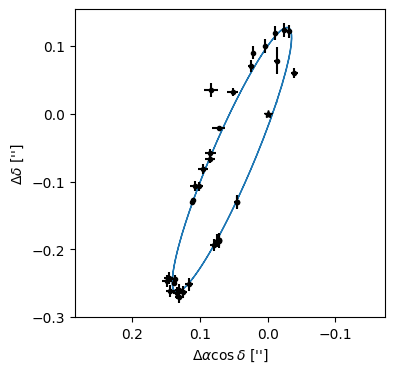

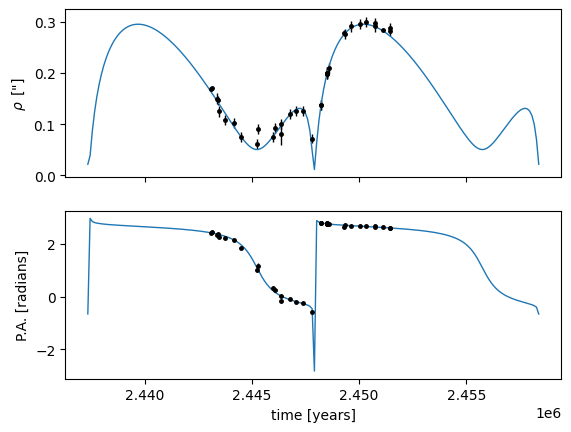

In [8]:
t = np.linspace(T0 - P, T0 + P, num=200)  # days
rho, theta = secondary.relative_angles(t, parallax=parallax)
xs, ys, _ = secondary.relative_position(t, parallax=parallax)

fig, ax = plt.subplots(nrows=1, figsize=(4, 4))

ax.plot(ys, xs, color="C0", lw=1)

ax.errorbar(ys_data, xs_data, xerr=ys_data_err, yerr=xs_data_err, fmt=".k")
ax.set_ylabel(r"$\Delta \delta$ ['']")
ax.set_xlabel(r"$\Delta \alpha \cos \delta$ ['']")
ax.invert_xaxis()
ax.plot(0, 0, "k*")
ax.set_aspect("equal", "datalim")
plt.show()

fig, ax = plt.subplots(nrows=2, sharex=True)
ax[0].errorbar(astro_jds, rho_data, yerr=rho_err, fmt=".k", lw=1, ms=5)
ax[0].plot(t, rho, color="C0", lw=1)
ax[0].set_ylabel(r'$\rho\,$ ["]')

ax[1].errorbar(astro_jds, theta_data, yerr=theta_err, fmt=".k", lw=1, ms=5)
ax[1].plot(t, theta, color="C0", lw=1)
ax[1].set_ylabel(r"P.A. [radians]")
_ = ax[1].set_xlabel("time [years]")
plt.show()

## Inference with NumPyro

### Building the model

Now that we know how to generate astrometric coordinates, we can wrap this in a NumPyro model to sample the posterior.
The first function generates an orbit for a set of parameters while the second implements the full probabilistic model.

In [9]:
import numpyro
from numpyro import distributions as dist, infer
import numpyro_ext.distributions as distx
import jax.numpy as jnp

t_fine = np.linspace(astro_jds.min() - 500, astro_jds.max() + 500, num=1000)

def astrometry_model(time, params):
    system = System(
        Central(mass=params["m_tot"], radius=1.0)
    ).add_body(
        Body(
            time_peri=params["T0"],
            period=params["P"],
            inclination=params["i"],
            eccentricity=params["e"],
            omega_peri=params["omega"],
            sin_asc_node=jnp.sin(params["Omega"]),
            cos_asc_node=jnp.cos(params["Omega"]),
            parallax=params["parallax"],
        )
    )
    return system.bodies[0].relative_angles(time, parallax=params["parallax"])

def model(parallax=None):
    if parallax is None:
        # Without actual parallax, set to 1 as a conversion constant
        plx = 1  # arcsec
    else:
        # If the parallax is provided in mas, we convert to arcsec
        m_plx = numpyro.sample("m_plx", dist.TruncatedNormal(loc=parallax[0], scale=parallax[1], low=0.0, high=100.0))
        plx = numpyro.deterministic("plx", 1e-3 * m_plx)

    # Angular semi-major axis in arcsec, converted to AU (or dummy units) through the parallax
    a_ang = numpyro.sample("a_ang", dist.Uniform(0.1, 1.0))
    a = numpyro.deterministic("a", a_ang / plx)

    # Broad prior on logP around 25 years
    logP = numpyro.sample("logP", dist.Normal(loc=np.log(25 * 365.25), scale=10.0))
    P = numpyro.deterministic("P", jnp.exp(logP))

    # Alternative parametrization for omega and Omega
    p = numpyro.sample("p", distx.Angle())
    m = numpyro.sample("m", distx.Angle())
    omega = numpyro.deterministic("omega", p - m)
    Omega = numpyro.deterministic("Omega", p + m)

    # Fit a phase for the time of periastron
    phase = numpyro.sample("phase", distx.Angle())
    tperi = numpyro.deterministic("tperi", T0 + P * phase / (2 * np.pi))

    # Uniform prior on cos(incl)
    cos_incl = numpyro.sample("cos_incl", dist.Uniform(-1, 1))
    incl = numpyro.deterministic("incl", jnp.arccos(cos_incl))
    ecc = numpyro.sample("ecc", dist.Uniform(0, 1))

    # Derive the total mass *note the conversion of a from AU to Rsun
    m_tot = numpyro.deterministic("m_tot", (4 * np.pi * np.pi * (a * au_to_R_sun)**3 / (G_grav * P**2)))

    # Compute the relative astrometry
    params = {
        "m_tot": m_tot,
        "T0": tperi,
        "P": P,
        "e": ecc,
        "i": incl,
        "omega": omega,
        "Omega": Omega,
        "parallax": plx,
    }
    rho_model, theta_model = astrometry_model(astro_jds, params)

    # Track the model values for the astrometry
    numpyro.deterministic("rho_model", rho_model)
    numpyro.deterministic("theta_model", theta_model)

    # Extra error term to sep and PA
    log_rho_s = numpyro.sample("log_rho_s", dist.Normal(loc=np.log(np.median(rho_err)), scale=2.0))
    log_theta_s = numpyro.sample("log_theta_s", dist.Normal(loc=np.log(np.median(theta_err)), scale=2.0))
    rho_tot_err = jnp.sqrt(rho_err**2 + jnp.exp(2 * log_rho_s))
    theta_tot_err = jnp.sqrt(theta_err**2 + jnp.exp(2 * log_theta_s))

    # Likelihood on rho and theta
    # The likelihood for theta accounts for wrapping of the angle
    numpyro.sample("rho_obs", dist.Normal(loc=rho_model, scale=rho_tot_err), obs=rho_data)
    theta_diff = jnp.arctan2(
        jnp.sin(theta_model - theta_data), jnp.cos(theta_model - theta_data)
    )
    numpyro.sample("theta_obs", dist.Normal(loc=theta_diff, scale=theta_tot_err), obs=0.0)

    # Save finer grid for plotting
    rho_dense, theta_dense = astrometry_model(t_fine, params)
    rho_save = numpyro.deterministic("rho_save", rho_dense)
    theta_save = numpyro.deterministic("theta_save", theta_dense)

### Checking the prior

It is always a good idea to first take a look at prior samples.
This allows us to easily spot errors in the model specification.

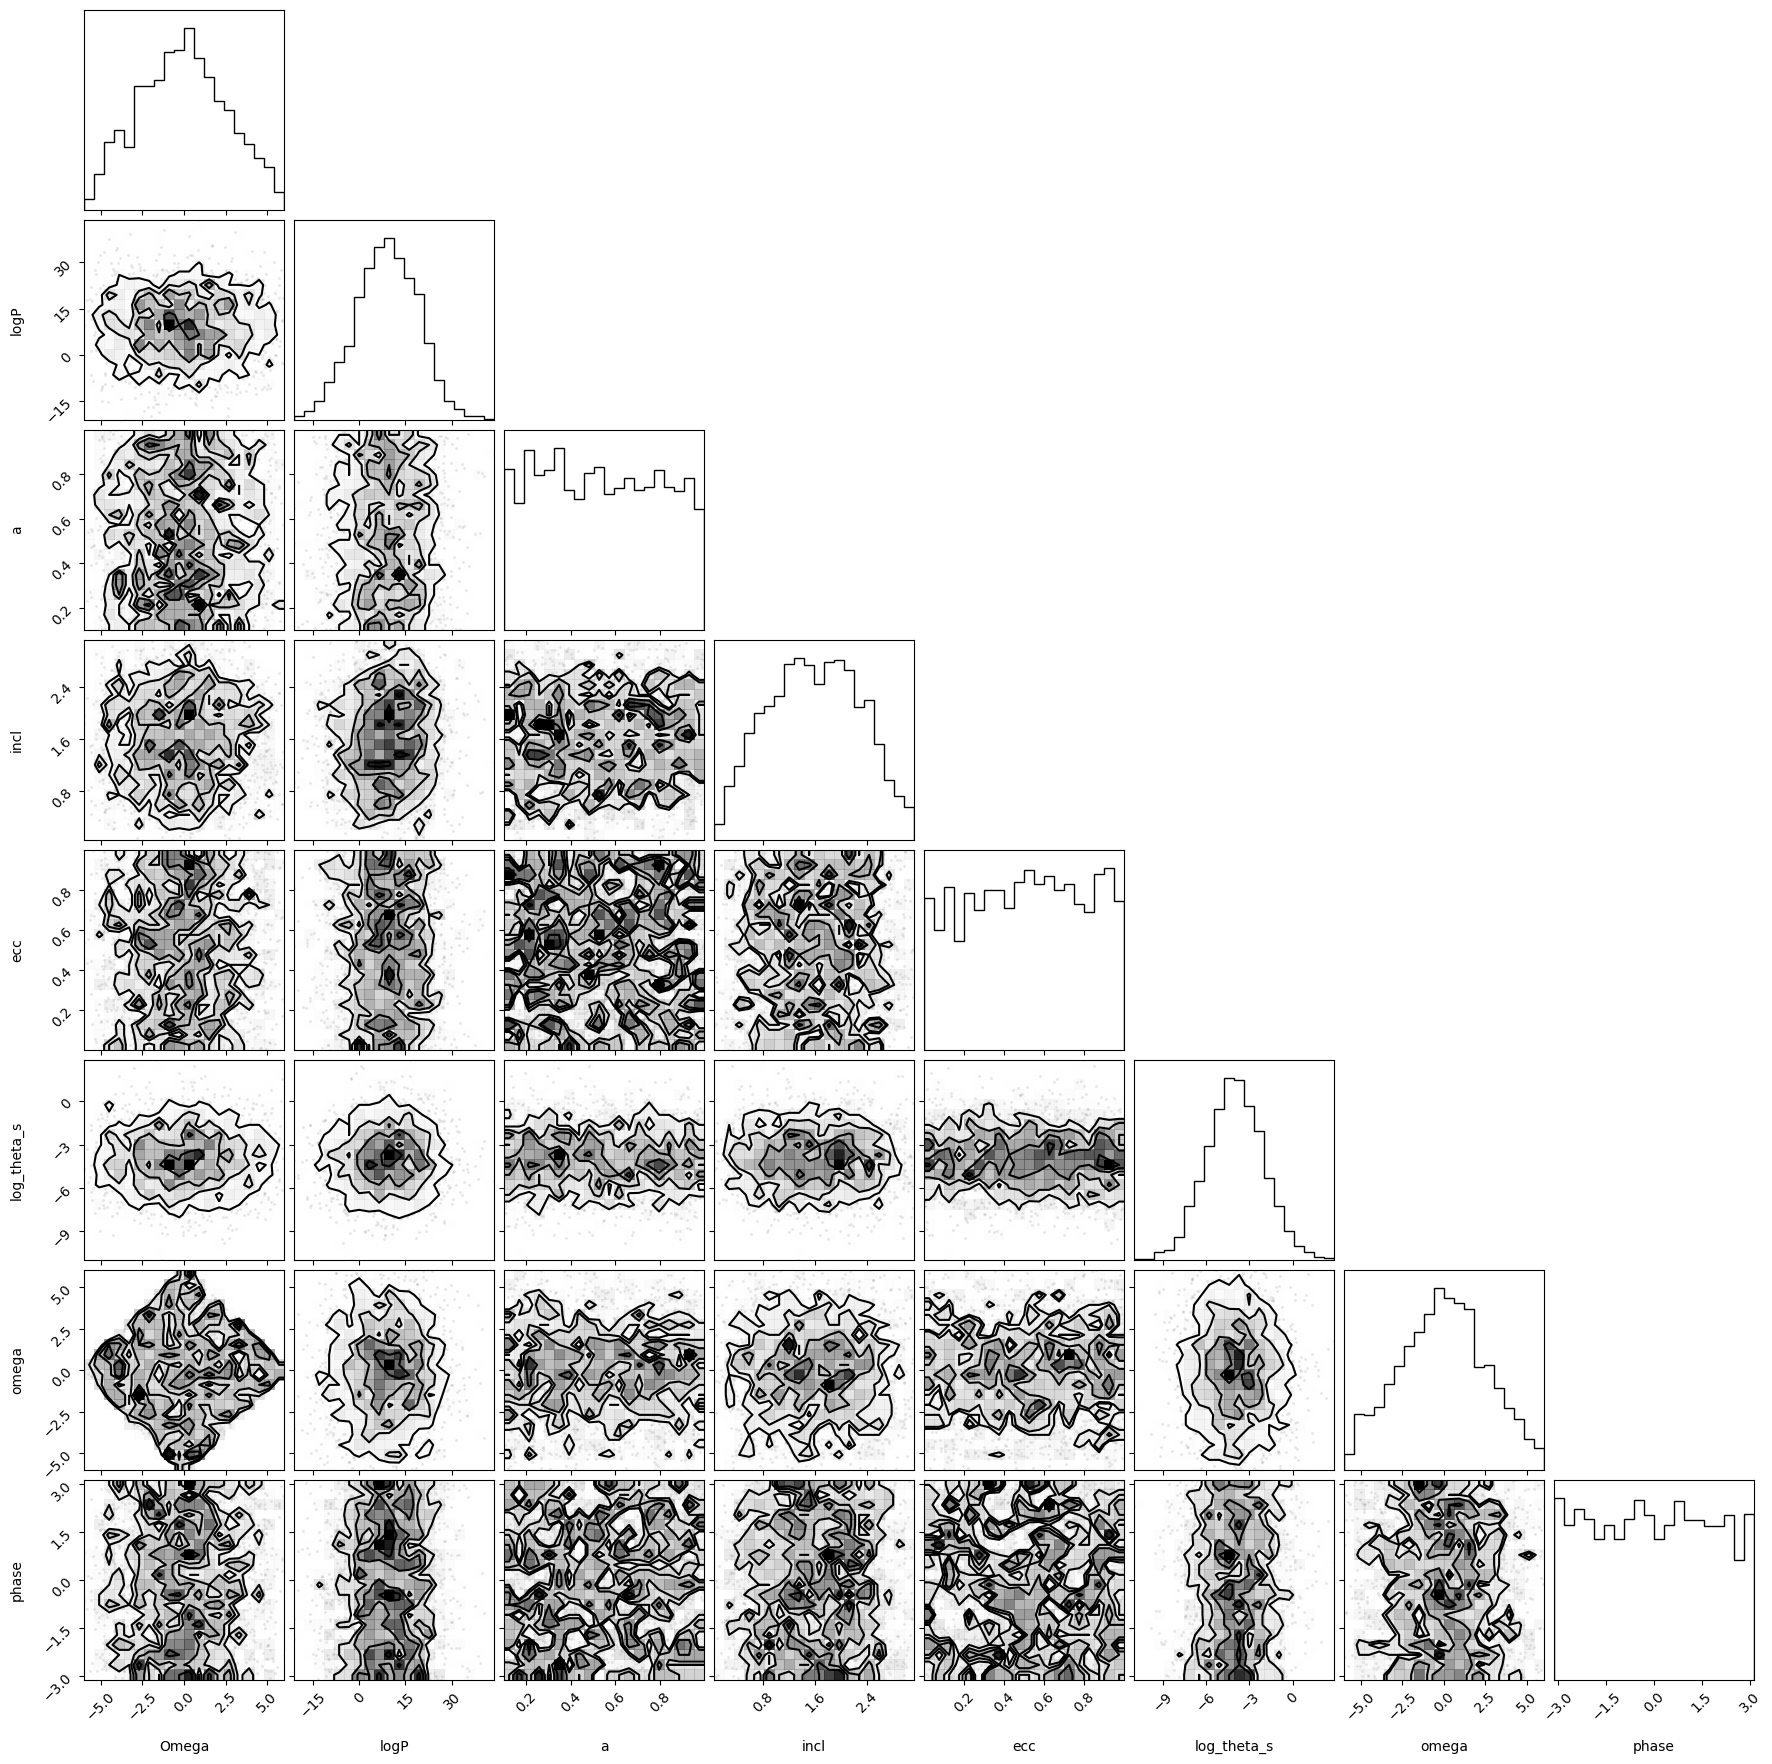

In [10]:
import arviz as az
import corner
n_prior_samples = 2000

key = jax.random.key(0)

key, subkey = jax.random.split(key)
prior_samples = infer.Predictive(model, num_samples=n_prior_samples)(subkey)

converted_prior_samples = {
    f"{p}": np.expand_dims(prior_samples[p], axis=0) for p in prior_samples
}
var_names = ["Omega", "logP", "a", "incl", "ecc", "log_rho_s_", "log_theta_s", "omega", "phase"]
prior_idata = az.from_dict({"prior": converted_prior_samples})

corner.corner(prior_idata, var_names=var_names, group="prior")
plt.show()

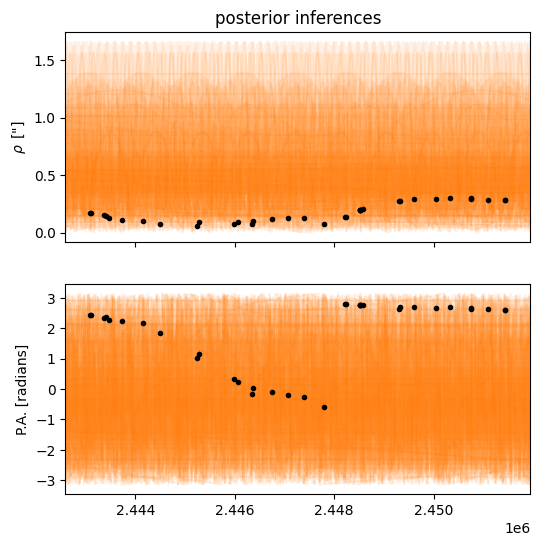

In [11]:
ekw = dict(fmt=".k", lw=0.5)

n_plots = 100

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(6, 6))
ax[0].set_ylabel(r'$\rho\,$ ["]')
ax[1].set_ylabel(r"P.A. [radians]")

ax[0].errorbar(astro_jds, rho_data, yerr=rho_err, **ekw)

ax[1].errorbar(astro_jds, theta_data, yerr=theta_err, **ekw)

rng = np.random.default_rng()
plot_inds = rng.integers(n_prior_samples, size=n_plots)
for idx in plot_inds:
    ax[0].plot(t_fine, prior_idata.prior["rho_save"].values[0, idx], "C1", alpha=0.1)
    ax[1].plot(t_fine, prior_idata.prior["theta_save"].values[0, idx], "C1", alpha=0.1)

ax[-1].set_xlim(t_fine[0], t_fine[-1])
_ = ax[0].set_title("posterior inferences")
plt.show()

### MAP Optimization

We can also optimize the model to find the maximum a posteriori parameters.

In [12]:
import numpyro_ext.optim as optimx
def optimize_model(key, parallax=None):
    opt_sites = [
        ["log_rho_s", "log_theta_s"],
        ["phase"],
        ["p", "m", "ecc"],
        ["logP", "a_ang", "phase"],
        None,
    ]
    omega0 = 251.6 * deg - np.pi
    Omega0 = 159.6 * deg
    start = {
        "a_ang": 0.324,
        "logP": np.log(28.8 * 365.25),
        "p": 0.5 * (Omega0 + omega0),
        "m": 0.5 * (Omega0 - omega0),
        "phase": 0.0,
        "cos_incl": np.cos(96 * deg),
        "ecc": 0.798,
    }
    for i, sites in enumerate(opt_sites):
        if i == 0:
            init = infer.init_to_value(values=start)
        else:
            init = infer.init_to_value(values=map_soln)
        key, subkey = jax.random.split(key)
        map_soln = optimx.optimize(model, sites=sites, init_strategy=init)(subkey, parallax=parallax)
    return map_soln
key, subkey = jax.random.split(key)
map_soln = optimize_model(subkey)

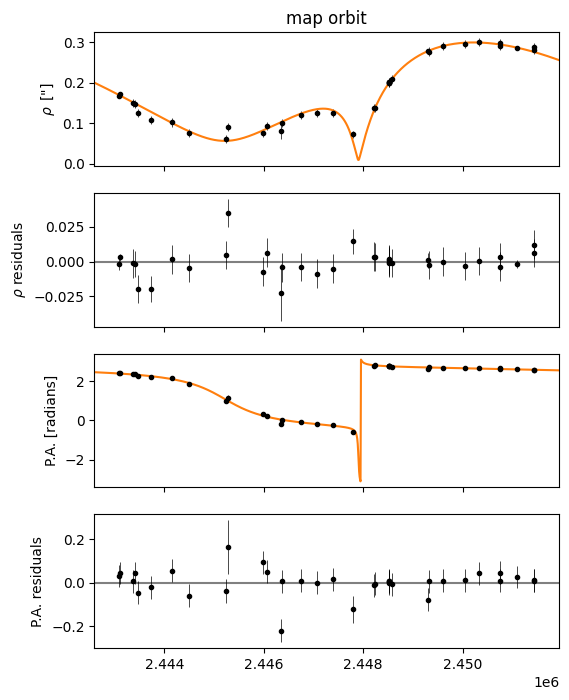

In [13]:
ekw = dict(fmt=".k", lw=0.5)

fig, ax = plt.subplots(nrows=4, sharex=True, figsize=(6, 8))
ax[0].set_ylabel(r'$\rho\,$ ["]')
ax[1].set_ylabel(r"$\rho$ residuals")
ax[2].set_ylabel(r"P.A. [radians]")
ax[3].set_ylabel(r"P.A. residuals")

tot_rho_err = np.sqrt(rho_err**2 + np.exp(2 * map_soln["log_rho_s"]))
tot_theta_err = np.sqrt(theta_err**2 + np.exp(2 * map_soln["log_theta_s"]))

ax[0].errorbar(astro_jds, rho_data, yerr=tot_rho_err, **ekw)
ax[0].plot(t_fine, map_soln["rho_save"], "C1")

ax[1].axhline(0.0, color="0.5")
ax[1].errorbar(
    astro_jds, rho_data - map_soln["rho_model"], yerr=tot_rho_err, **ekw
)


ax[2].plot(t_fine, map_soln["theta_save"], "C1")
ax[2].errorbar(astro_jds, theta_data, yerr=tot_theta_err, **ekw)

ax[3].axhline(0.0, color="0.5")
ax[3].errorbar(
    astro_jds, theta_data - map_soln["theta_model"], yerr=tot_theta_err, **ekw
)

ax[3].set_xlim(t_fine[0], t_fine[-1])
_ = ax[0].set_title("map orbit")
plt.show()

### Sampling

And finally, we can sample the posterior.

In [14]:
def sample_model(key, parallax=None):
    sampler = infer.MCMC(
        infer.NUTS(
            model,
            dense_mass=True,
            regularize_mass_matrix=True,
            init_strategy=infer.init_to_value(values=map_soln)
        ),
        num_warmup=1000,
        num_samples=1000,
        num_chains=2,
        progress_bar=True,
    )
    key, subkey = jax.random.split(key)
    sampler.run(subkey, parallax=parallax)
    return sampler
key, subkey = jax.random.split(key)
sampler = sample_model(subkey)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [15]:
idata = az.from_numpyro(sampler)

In [16]:
az.summary(
    idata,
    var_names=["P", "tperi", "a_ang", "omega", "Omega", "incl", "ecc"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
P,10435,144,10000,11000,1572,1188,1.00,3.8,3.6
tperi,2.44786e+06,20.3,2.4e+06,2.4e+06,1971,1526,1.00,0.46,0.32
a_ang,0.3183,0.0079,0.31,0.33,1806,1583,1.00,0.00018,0.00014
omega,1.2351,0.0138,1.2,1.3,1618,1487,1.00,0.00034,0.00024
Omega,2.7874,0.0113,2.8,2.8,2092,1712,1.00,0.00025,0.00018
incl,1.6904,0.0062,1.7,1.7,1938,1403,1.00,0.00014,0.0001
ecc,0.7776,0.0124,0.76,0.8,1640,1244,1.00,0.00031,0.00023


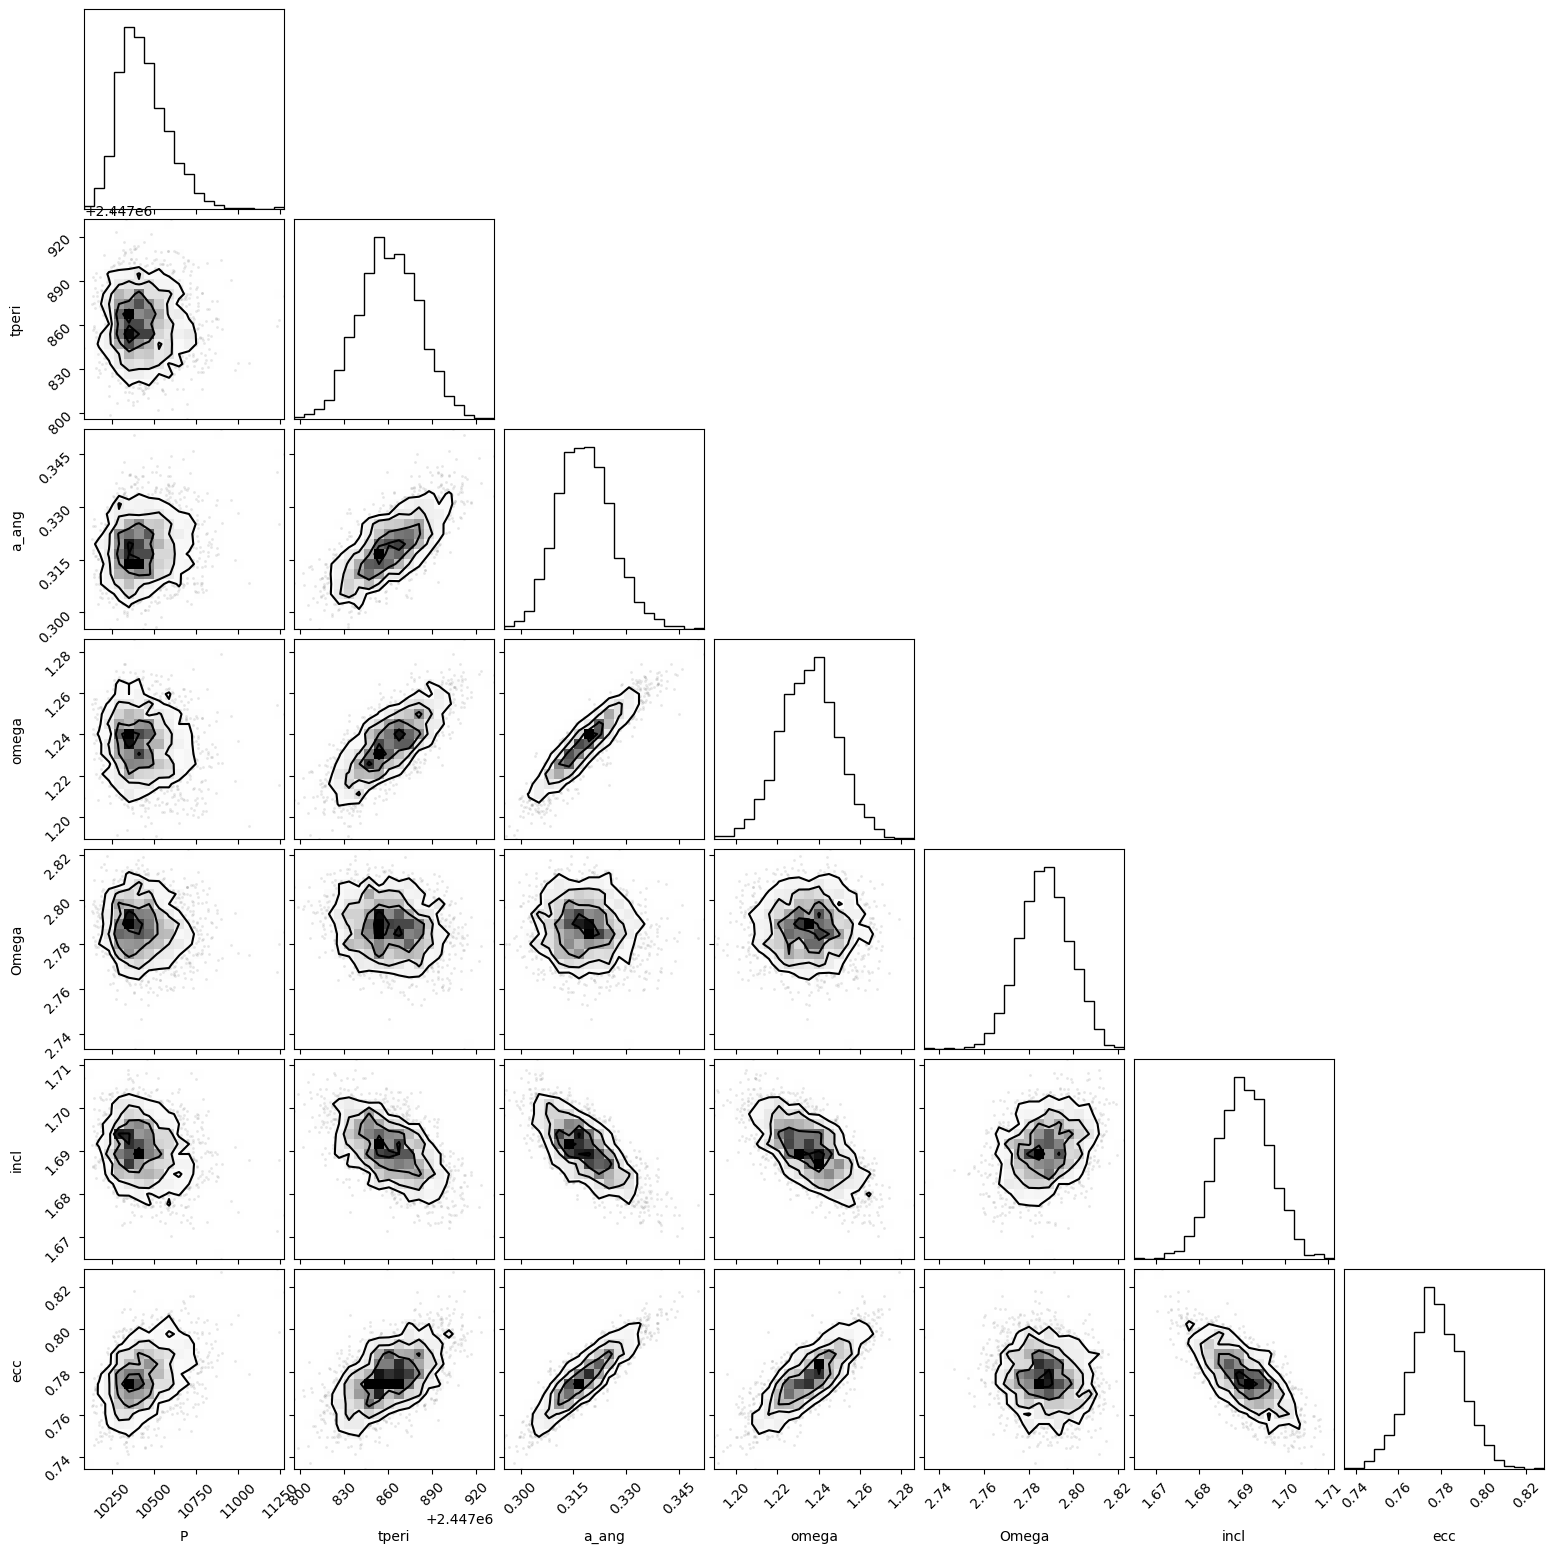

In [17]:
corner.corner(
    idata, var_names=["P", "tperi", "a_ang", "omega", "Omega", "incl", "ecc"]
)
plt.show()

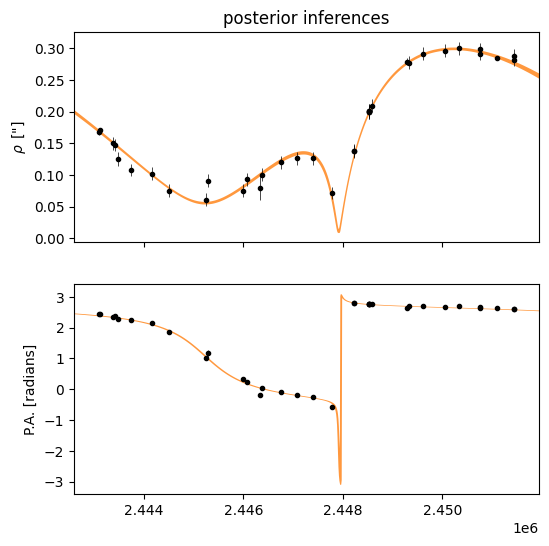

In [18]:
ekw = dict(fmt=".k", lw=0.5)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(6, 6))
ax[0].set_ylabel(r'$\rho\,$ ["]')
ax[1].set_ylabel(r"P.A. [radians]")

tot_rho_err = np.sqrt(
    rho_err**2
    + np.exp(2 * np.median(idata.posterior["log_rho_s"].values, axis=(0, 1)))
)
tot_theta_err = np.sqrt(
    theta_err**2
    + np.exp(2 * np.median(idata.posterior["log_theta_s"].values, axis=(0, 1)))
)

ax[0].errorbar(astro_jds, rho_data, yerr=tot_rho_err, **ekw)
q = np.percentile(idata.posterior["rho_save"].values, [16, 84], axis=(0, 1))
ax[0].fill_between(t_fine, q[0], q[1], color="C1", alpha=0.8, lw=0)

ax[1].errorbar(astro_jds, theta_data, yerr=tot_theta_err, **ekw)
q = np.percentile(idata.posterior["theta_save"].values, [16, 84], axis=(0, 1))
ax[1].fill_between(t_fine, q[0], q[1], color="C1", alpha=0.8, lw=0)

ax[-1].set_xlim(t_fine[0], t_fine[-1])
_ = ax[0].set_title("posterior inferences")
plt.show()

## Including parallax

The model above had an unphysical total mass (and hence semi-major axis) value.
We can obtain a more realistic model by specifying the parallax of the system.

Since we had already coded that option in the model above,
we only need to pass it as an argument during optimization and sampling.

In [19]:
key, subkey = jax.random.split(key)
parallax = [24.05, 0.45]
plx_map_soln = optimize_model(subkey, parallax=parallax)

In [20]:
key, subkey = jax.random.split(key)
plx_sampler = sample_model(subkey, parallax=parallax)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [21]:
plx_idata = az.from_numpyro(plx_sampler)

In [22]:
az.summary(
    plx_idata,
    var_names=["P", "tperi", "a_ang", "omega", "Omega", "incl", "ecc", "m_tot", "plx"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
P,10436,147,10000,11000,1563,1333,1.00,3.9,3.7
tperi,2.44786e+06,21.6,2.4e+06,2.4e+06,2081,1524,1.00,0.48,0.34
a_ang,0.3186,0.0085,0.31,0.33,1775,1227,1.00,0.00021,0.00016
omega,1.2355,0.0152,1.2,1.3,1828,1383,1.00,0.00035,0.00026
Omega,2.7876,0.0117,2.8,2.8,2048,1428,1.00,0.00026,0.00019
incl,1.6905,0.0065,1.7,1.7,1781,1592,1.00,0.00016,0.00011
ecc,0.7779,0.0132,0.76,0.8,1726,1237,1.00,0.00032,0.00023
m_tot,2.86,0.28,2.4,3.3,2042,1454,1.00,0.0064,0.005
plx,0.02405,0.00044,0.023,0.025,2922,1636,1.00,8.1e-06,5.8e-06


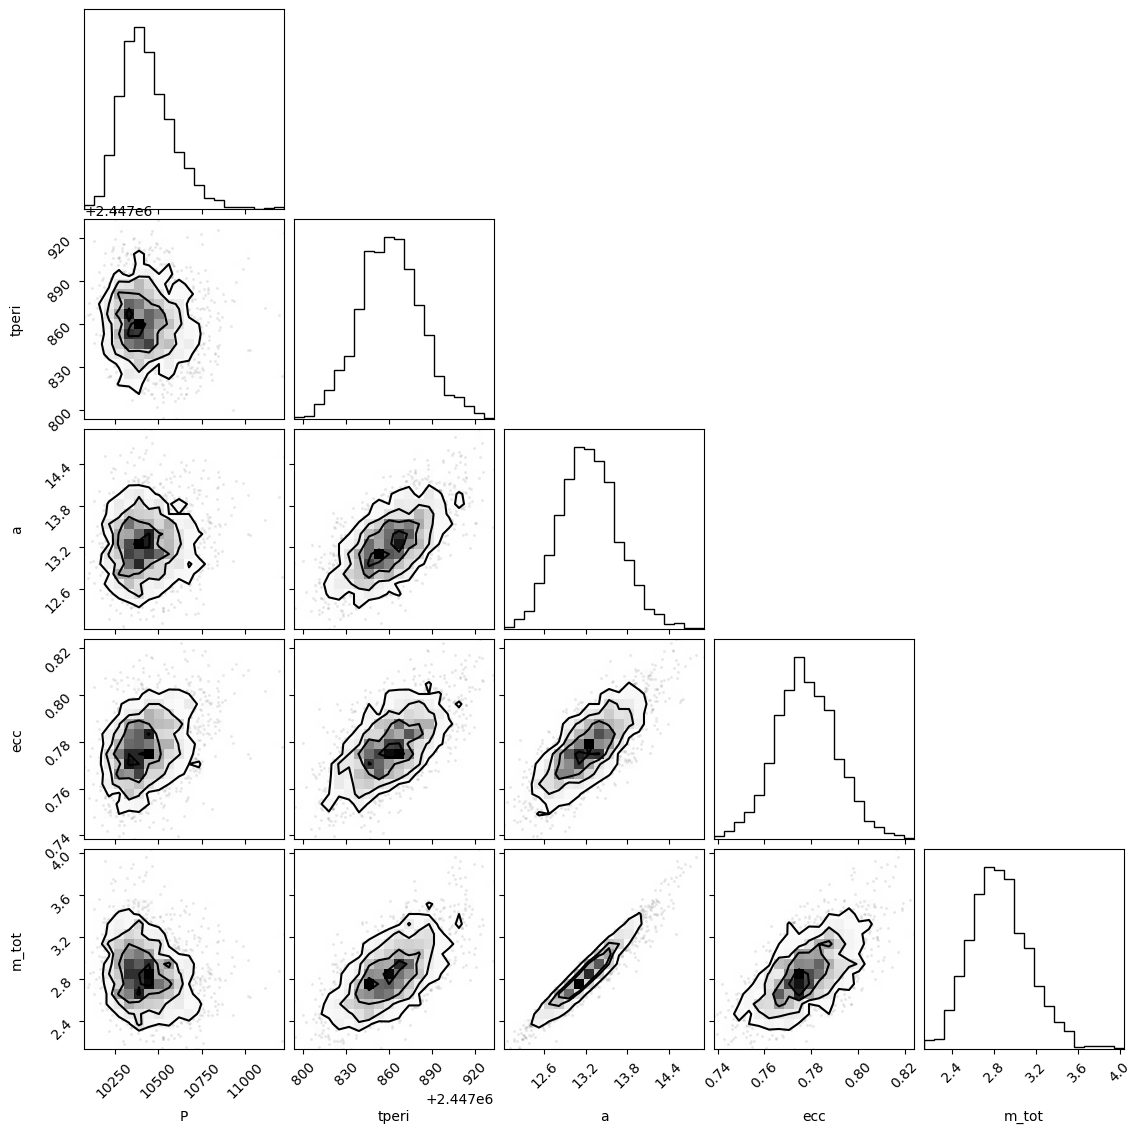

In [23]:
corner.corner(
    plx_idata, var_names=["P", "tperi", "a", "ecc", "m_tot"]
)
plt.show()